# Fraction of Variance explain by the annual and semi-annual cycles Plotting

**Purpose**: Code for plotting the fraction of variance explain by the annual and semi-annual from model and observation for each analysis (mooring, cross-shelf transect, regional)

**Luke Colosi | lcolosi@ucsd.edu**

Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from datetime import datetime, timedelta
import cmocean.cm as cmo
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.gridspec as gridspec
from netCDF4 import Dataset, num2date
import xarray as xr

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
from plotScaleAnalysis import add_corner_label, add_freq_marker
import cartopy_figs as cart

Set plotting parameters

In [2]:
# Set the path
PATH_mooring_obs  = ROOT + 'AirSeaCoupling/data/CCE/'
PATH_mooring_m    = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/temporal/'
PATH_transect     = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/spatial/transect/'
PATH_regional     = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/spatial/'
PATH_bathy        = ROOT + 'AirSeaCoupling/data/bathymetry/'
PATH_calCOFI      = ROOT + 'AirSeaCoupling/data/calCOFI/'
PATH_figs         = ROOT + 'AirSeaCoupling/figs/paper_figures/'

# Set time and space parameters  
lat_bnds     = [33, 35]                      # Specifies the latitude bounds for the region to analyze
lon_bnds     = [-123 % 360, -120 % 360]      # Specifies the longitude bounds for the region to analyze

# Set plotting parameters for cartopy functions
projection = ccrs.PlateCarree(central_longitude=0.0)
xticks = [-123, -122, -121, -120]
yticks = [33.25, 33.50, 33.75, 34.00, 34.25, 34.50, 34.75, 35.00]
resolution = "10m"
bounds = np.arange(0,360+40,40)

# Set font and fontsize
os.environ["PATH"] = "/usr/local/texlive/2022/bin/universal-darwin:" + os.environ["PATH"]
fontsize = 15
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
    "text.usetex": True,           # Use LaTeX for all text
    "font.family": "serif",        # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
}) 

Load in data

In [3]:
#-------------------------------------------------------#
# Mooring Analysis
#-------------------------------------------------------#
filename_m    = PATH_mooring_m + "mitgcm_density_temporal_scale_data.npz"
filename_cce1 = PATH_mooring_obs + "CCE1/CTD/CCE1_CTD_201611-20171231_scale_data_gridded.npz"
filename_cce2 = PATH_mooring_obs + "CCE2/CTD/CCE2_CTD_202011-20211231_scale_data_gridded.npz"

# Load data 
ds_m    = np.load(filename_m, allow_pickle=True)
ds_cce1 = np.load(filename_cce1, allow_pickle=True)
ds_cce2 = np.load(filename_cce2, allow_pickle=True)

# Extract data variables
fve_sig_m   = ds_m['fve_seg']      
depth_m     = ds_m['depth']    
lat_m       = ds_m['lat'] 
lon_m       = ds_m['lon']   

fve_sig_cce1 = ds_cce1['fve_sig_seg']
fve_sig_cce2 = ds_cce2['fve_sig_seg']
depth_cce1   = ds_cce1['depth']
depth_cce2   = ds_cce2['depth']

#-------------------------------------------------------#
# Cross-shelf transect Analysis
#-------------------------------------------------------#
filename_t  = PATH_transect + "mitgcm_transect_spatial_gradients.npz"

# Load data 
ds_t   = np.load(filename_t, allow_pickle=True)

# Extract data variables
fve_sig_t    = ds_t['fve_sig']      
dist_t       = ds_t['dist']
depth_t      = ds_t['depth']   
lat_t        = ds_t['lat']    
lon_t        = ds_t['lon'] 

#-------------------------------------------------------#
# Regional Analysis
#-------------------------------------------------------#
filename_r = PATH_regional + "mitgcm_regional_spatial_gradients.npz"

# Load data 
ds_r   = np.load(filename_r, allow_pickle=True)

# Extract data variables
fve_sig_r     = ds_r['fve_sig']     
depth_r       = ds_r['depth']   
lat_r         = ds_r['lat']    
lon_r         = ds_r['lon'] 

#-------------------------------------------------------#
# Ocean Bottom along CalCOFI line 80.0
#-------------------------------------------------------#
filename_ob = PATH_transect + "ocean_bottom_CCS4_transect_calCOFI_line80.nc"

# Load data
nc = Dataset(filename_ob, 'r')

# Extract data variables
bottom_depth = nc.variables['bottom_depth'][:]

# Reverse order of bottom depth 
bottom_depth = bottom_depth[::-1]

#-------------------------------------------------------#
# Mooring Locations
#-------------------------------------------------------#

#--- CCE 1 ---# 
lon1 = -122.52233 
lat1 = 33.457

#--- CCE 2 ---# 
lon2 = -120.8042 
lat2 = 34.3075

#--- CCE 3 ---# 
lon3 = -120.53825701527784
lat3 = 34.44825228022894

#--- Shore ---# 
lon_shore = -120.483310
lat_shore = 34.482942

Read in bathymetry data

In [4]:
# Load bathymetry data 
filename = PATH_bathy + "topo_25.1.nc"
ds_bathy = xr.open_dataset(filename, engine="netcdf4")

# Extract data variables
lon_b = ds_bathy["lon"]  # Longitude
lat_b = ds_bathy["lat"]  # Latitude
bathy = ds_bathy["z"]    # Elevation/Bathymetry

# Convert convesion of longitude (neg from the prime meridian to positive definite wrapping around the earth)
lon_n = lon_b % 360

# Set max and min values 
lon_min = lon_bnds[0]
lon_max = lon_bnds[1]
lat_min = lat_bnds[0]
lat_max = lat_bnds[1]

# Extract data from bathymetry 
lon_grid = lon_n[(lon_n >= lon_min) & (lon_n <= lon_max)]
lat_grid = lat_b[(lat_b >= lat_min) & (lat_b <= lat_max)]
bathy_grid   = bathy[(lat_b >= lat_min) & (lat_b <= lat_max),(lon_n >= lon_min) & (lon_n <= lon_max)]

Read in CalCOFI stations

In [5]:
# Load CalCOFI csv file 
filename = PATH_calCOFI + "CalCOFIStationOrder.csv"
calCOFI_data = np.genfromtxt(
    filename,
    delimiter=",",
    skip_header=1,
    usecols=(1, 3, 7, 11),
    invalid_raise=False
)

# Grab stations on line 80.0
calCOFI_line80 = calCOFI_data[calCOFI_data[:, 0] == 80.0] 

# Parse data into separate arrays
calCOFI_stn   = calCOFI_line80[:, 0]
calCOFI_lat   = calCOFI_line80[:, 1]
calCOFI_lon   = calCOFI_line80[:, 2]
calCOFI_depth = calCOFI_line80[:, 3]

Clean up data

In [6]:
# Set the depth of model data to the upper 200 meters 
depth_m = depth_m[depth_m >= -215]

# Mask zero fill values 
fve_sig_m = np.ma.masked_where(fve_sig_m == 0, fve_sig_m)
fve_sig_r = np.ma.masked_where(fve_sig_r == 0, fve_sig_r)

# Slice the data so that the analysis only considers the offshore distances up to 123 degrees west

# Find the indices specified by lat and lon bounds
dist_mask = ((lat_t >= lat_bnds[0]) & (lat_t <= lat_bnds[1]) & (lon_t >= lon_bnds[0]) & (lon_t <= lon_bnds[1]))
idx_dist  = np.where(dist_mask)[0]

# Extract indices for upper 200 meters and specified lat and lon bounds
bottom_depth = bottom_depth[idx_dist]

Plot the FVE 

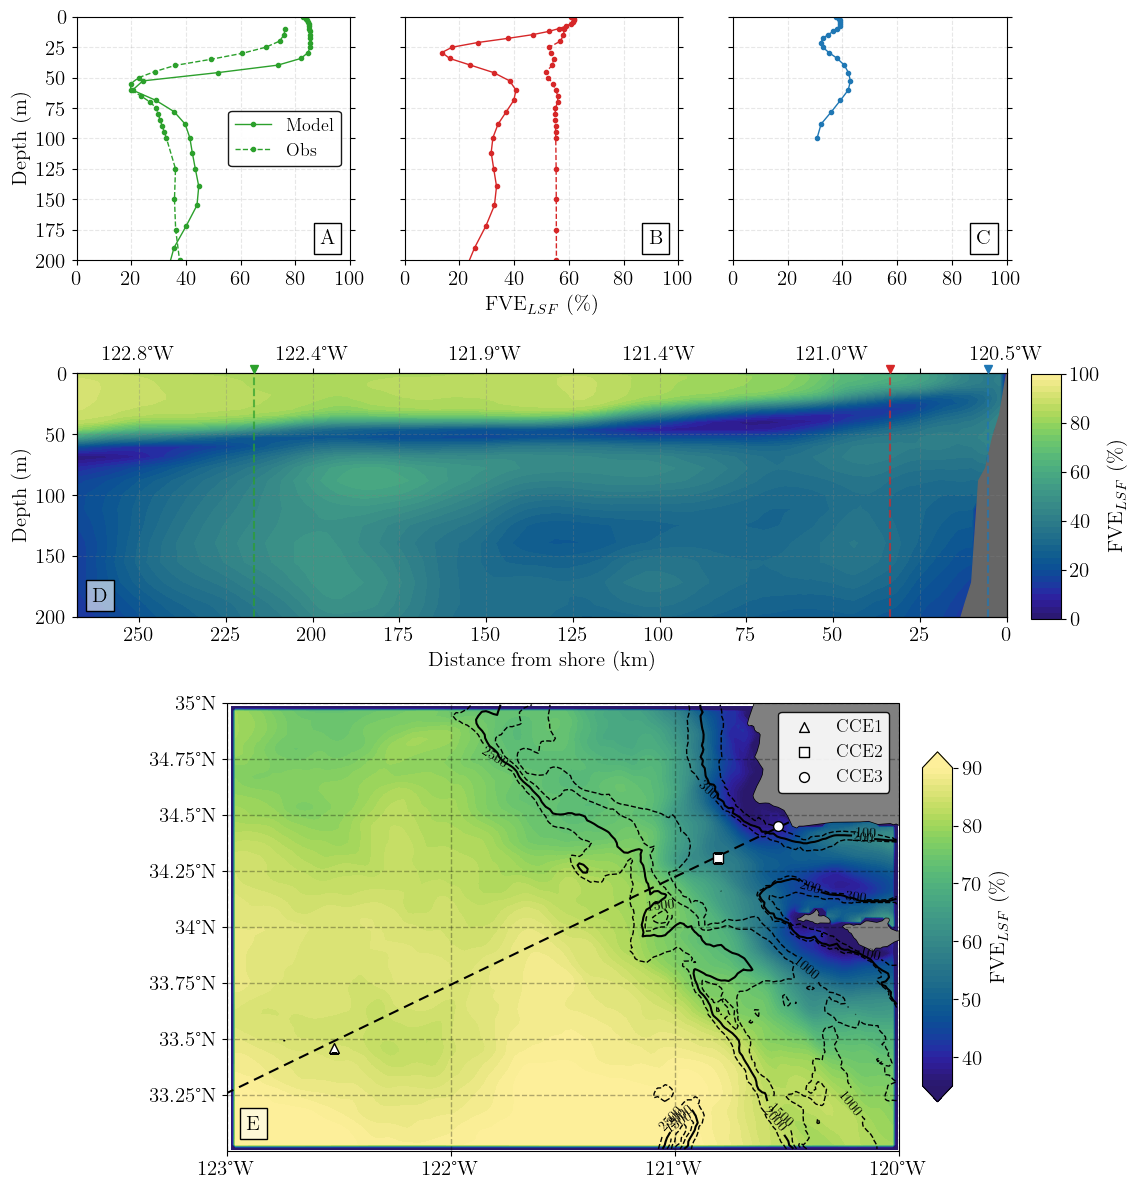

In [7]:
# Set plotting parameters
levels_t = np.arange(0,100+2.5,2.5)
levels_r = np.arange(35,90+1,1)
cmap = cmo.haline
axes = []

# ---------------------------
# Create figure and axes format
# ---------------------------
fig = plt.figure(figsize=(12, 14))

gs = gridspec.GridSpec(
    nrows=3,
    ncols=3,
    height_ratios=[1, 1, 1.5],  # bottom panel larger
    hspace=0.4,
    wspace=0.2
)

#--- Subplot 1 ---# 
ax = fig.add_subplot(gs[0, 0])
axes.append(ax)

# Plot the FVE for model and observations at CCE1 
ax.plot(fve_sig_m[0,:]*100, abs(depth_m), '.-', color='tab:green', linewidth=1,label='Model')
ax.plot(fve_sig_cce1*100, abs(depth_cce1), '.--', color='tab:green', linewidth=1, label = 'Obs')

# Set figure attributes
#ax.set_xlabel(r'FVE ($\%$)')
ax.set_ylabel("Depth (m)")
ax.set_xlim(0,100)
ax.set_ylim(0,200)
ax.set_xticks(np.arange(0,100+20,20))
ax.set_yticks(np.arange(0,200+25,25))
ax.invert_yaxis()
ax.tick_params(top=False, bottom=True, left=True, right=True,
               direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3)
ax.legend(loc='right', fontsize=fontsize-2, framealpha=0.9, edgecolor='black')

#--- Subplot 2 ---# 
ax = fig.add_subplot(gs[0, 1])
axes.append(ax)

# Plot the FVE for CCE1 
ax.plot(fve_sig_m[1,:]*100, abs(depth_m), '.-', color='tab:red', linewidth=1)
ax.plot(fve_sig_cce2*100, abs(depth_cce2), '.--', color='tab:red', linewidth=1)

# Set figure attributes
ax.set_xlabel(r'FVE$_{LSF}$ ($\%$)')
ax.set_xlim(0,100)
ax.set_ylim(0,200)
ax.set_xticks(np.arange(0,100+20,20))
ax.set_yticks(np.arange(0,200+25,25))
ax.set_yticklabels([])
ax.invert_yaxis()
ax.tick_params(top=False, bottom=True, left=True, right=True,
               direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 3 ---# 
ax = fig.add_subplot(gs[0, 2])
axes.append(ax)

# Plot the FVE for CCE1 
ax.plot(fve_sig_m[2,:]*100, abs(depth_m), '.-', color='tab:blue', linewidth=1)

# Set figure attributes
#ax.set_xlabel(r'FVE ($\%$)')
ax.set_xlim(0,100)
ax.set_ylim(0,200)
ax.set_xticks(np.arange(0,100+20,20))
ax.set_yticks(np.arange(0,200+25,25))
ax.set_yticklabels([])
ax.invert_yaxis()
ax.tick_params(top=False, bottom=True, left=True, right=True,
               direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 4 ---# 
ax = fig.add_subplot(gs[1, :])
axes.append(ax)

# Plot time-mean data
cf = ax.contourf(dist_t,abs(depth_t),(fve_sig_t*100).T, levels=levels_t, cmap=cmap, extend='neither')

# Plot the ocean bottom depth 
ax.fill_between(dist_t, abs(bottom_depth), abs(depth_t[-1]), color='0.4') 

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel('Depth (m)')
ax.set_xlim(0,dist_t[-1])
ax.set_ylim(0,200)
ax.set_xticks(np.arange(0,250+25,25))
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# Set colorbar
cax = fig.add_axes([0.92, 0.45, 0.025, 0.175])                              # [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='neither')
cbar.set_label(r'FVE$_{LSF}$ ($\%$)')
cbar.set_ticks(np.arange(0,100 + 20, 20))

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon_t + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist_t, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist_t[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

#--- Subplot 5 ---# 
ax = fig.add_subplot(gs[2, 0:3], projection = projection)
axes.append(ax)

# Set figure axes 
cart.set_subplots(ax, projection, resolution, lon_min=lon_min, lon_max=lon_max, lat_min=lat_min, lat_max=lat_max) 

# Plot the time mean of the potential density 
cf = ax.contourf(
    lon_r, lat_r, fve_sig_r*100, levels=levels_r,
    transform=ccrs.PlateCarree(),
    cmap=cmap,  
    extend = 'both'
)

# Plot depth contour lines
level_innershelf = [100, 300]
levels_midshelf = [1000, 1500, 2500]
contour1 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=levels_midshelf, colors='black', linewidths=1, linestyles='dashed')
contour2 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[2000], colors='black', linewidths=1.5, linestyles='solid')
contour3 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=level_innershelf, colors='black', linewidths=1, linestyles='dashed')
contour4 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[200], colors='black', linewidths=1.5, linestyles='solid')
plt.clabel(contour1, fontsize=10)
plt.clabel(contour2, fontsize=10)
plt.clabel(contour3, fontsize=10)
plt.clabel(contour4, fontsize=10)

#--- CCE Moorings ---# 

# Plot the mooring point
ax.scatter(
    lon1, lat1, 
    color='w',
    edgecolor='black', marker='^', s=50,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE1'
)

# Plot the mooring point
ax.scatter(
    lon2, lat2, 
    color='w',  # color from the same colormap
    edgecolor='black', marker='s', s=50,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE2'
)

# Plot the mooring point
ax.scatter(
    lon3, lat3, 
    color= 'w',  
    edgecolor='black', marker='o', s=50,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE3'
)

# Plot Line 80 CalCOFI Stations
ax.plot(
    calCOFI_lon % 360, calCOFI_lat,
    color='k',
    linestyle=(0, (5, 3)),   # (offset, (dash_length, gap_length))
    linewidth=1.5,
    transform=ccrs.PlateCarree()
)

# Set grid ticks 
cart.set_grid_ticks(
    ax,
    projection=ccrs.PlateCarree(),
    xticks=xticks,
    yticks=yticks,
    xlabels=True,
    ylabels=True,
    grid=True,
    fontsize=fontsize,
    color="black",
)

# Create colorbar
cax = fig.add_axes([0.83, 0.105, 0.025, 0.25]) 
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(r'FVE$_{LSF}$ ($\%$)')
cbar.set_ticks(np.arange(40, 90+10, 10))

# Set legend
ax.legend(
    loc='upper right',
    fontsize=fontsize-2,
    framealpha=0.9,
    edgecolor='black'
)

# Expand width manually
ax.set_position([0.08, 0.07, 0.9, 0.32])

# Label each subplot
add_corner_label(axes[0], [0.9175, 0.09], 'A', fontsize=fontsize)
add_corner_label(axes[1], [0.9175, 0.09], 'B', fontsize=fontsize)
add_corner_label(axes[2], [0.9175, 0.09], 'C', fontsize=fontsize)
add_corner_label(axes[3], [0.025, 0.085], 'D', fontsize=fontsize)
add_corner_label(axes[4], [0.04, 0.06], 'E', fontsize=fontsize)

# Display 
plt.show()

# Save figure in high resolution 
figName = 'fig09.png'

fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)